In [48]:
import numpy as np
import torch
from torch import linalg
import numpy as np
from scipy.stats import norm, uniform
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
rng = torch.manual_seed(10404)


In [41]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 30.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [43]:

def torch_random_orthog(n_dim, batch_shape=None, random_state=None):
    size = (n_dim, n_dim)
    if batch_shape is not None:
        size = tuple(batch_shape) + size

    if random_state is not None:
        gen = torch.Generator()
        gen.manual_seed(random_state)
        a = torch.randn(size=size, generator=gen)
    else:
        a = torch.randn(size=size)

    Q, R = torch.linalg.qr(a)
    return Q


In [44]:
def torch_dialect_arrays(n_dialect, batch_shape, random_state = None, eval_range= torch.tensor([.5,1.5])):
    U = torch_random_orthog(n_dialect, batch_shape=batch_shape, random_state=random_state)
    eval_scale = eval_range[1]-eval_range[0]
    d = eval_range[0] +eval_scale*torch.rand(size = tuple(batch_shape)+(n_dialect,))
    mu = torch.zeros(size = tuple(batch_shape)+(n_dialect,))*torch.sqrt(d)
    return U,d,mu

torch_dialect_arrays(n_dialect=2, batch_shape=(2,))

(tensor([[[-0.6665,  0.7455],
          [ 0.7455,  0.6665]],
 
         [[-0.9650, -0.2623],
          [-0.2623,  0.9650]]]),
 tensor([[0.9086, 1.0945],
         [1.4282, 0.6247]]),
 tensor([[0., 0.],
         [0., 0.]]))

In [45]:
def sample_from_dialects(nsamp, O_c, d_c, d, mu, U):
    n_common = d_c.shape[-1]
    n_dialect = d.shape[-1]
    batch_shape = d.shape[:-1]
   
    z_common = torch.randn(size=batch_shape + (nsamp, n_common))
    z_common = z_common * torch.sqrt(d_c)

    eps = torch.randn(size=batch_shape + (nsamp, n_dialect))
    z_dialect = eps * torch.sqrt(d[..., None, :]) + mu[..., None, :]

    Ut_z = (U.mT[..., None, :, :] @ z_dialect.unsqueeze(-1)).squeeze(-1)

    O_common  = O_c[:, :n_common]
    O_dialect = O_c[:, n_common:]

    x_common  = (z_common.unsqueeze(-2) @ O_common.mT).squeeze(-2)
    x_dialect = (Ut_z.unsqueeze(-2) @ O_dialect.mT).squeeze(-2)
    x_total   = x_common + x_dialect

    return x_common, x_dialect, x_total


def array_cov(O_c, d_c, d, mu, U):
    n_common = d_c.shape[-1]
    O_common = O_c[:, :n_common]
    O_dialect = O_c[:, n_common:]

    cov_common = O_common @ torch.diag(d_c) @ O_common.mT

    D = torch.diag_embed(d)
    UDU = U.mT @ D @ U
    cov_specific = O_dialect @ UDU @ O_dialect.mT

    cov_total = cov_common + cov_specific

    mu_col = mu.unsqueeze(-1)
    mean = (O_dialect @ (U.mT @ mu_col)).squeeze(-1)

    return cov_total, mean

def sampled_cov(sample):
    mean = sample.mean(dim=-2)
    centered = sample - mean.unsqueeze(-2)
    cov = centered.mT @ centered / (sample.shape[-2] - 1)
    return cov, mean





In [32]:




n_dialect   = 4
n_context   = 8
batch_shape = (50,)
nsamp       = 10_000       

U, d, mu = torch_dialect_arrays(n_dialect, batch_shape)
O_c      = torch_random_orthog(n_context)
d_c      = torch.tensor([0.8, 0.9, 1.0, 1.1])

sample = sample_from_dialects(nsamp, O_c, d_c, d, mu, U)

ana_cov,  ana_mean  = array_cov(O_c, d_c, d, mu, U)
samp_cov, samp_mean = sampled_cov(sample)

   
   

    

    print(ana_cov[0, :4, :4].round(decimals=3))
  
    print(samp_cov[0, :4, :4].round(decimals=3))

AttributeError: 'tuple' object has no attribute 'mean'

In [27]:
print(dialect_50)

tensor([[[-0.1184, -0.3426, -0.0758,  ...,  0.2157, -0.1734,  0.5364],
         [ 0.0218,  0.6750,  0.3053,  ..., -1.4562, -0.0731,  1.1600],
         [-1.0794,  0.7794,  0.5630,  ...,  0.8487, -0.3293, -0.1482],
         ...,
         [ 0.4694,  0.4372, -0.6578,  ..., -0.4523,  0.4810,  0.9704],
         [ 0.9682, -1.1434, -1.0961,  ...,  0.7068,  0.5076, -0.3716],
         [ 1.2060, -0.1119, -0.4470,  ..., -1.1336,  0.6242, -0.6722]],

        [[ 0.6580,  0.3136,  0.5417,  ..., -1.8296,  0.1438, -0.9343],
         [ 0.4328,  1.6675, -0.3053,  ..., -0.8170,  0.8489, -0.3209],
         [ 0.1317, -0.9159,  0.3973,  ..., -0.2088, -0.3651, -0.6687],
         ...,
         [-0.0881,  0.4295, -1.3133,  ...,  1.5302,  0.5851,  1.3832],
         [ 0.3013, -0.4286,  0.6838,  ..., -1.3340, -0.3260, -0.4665],
         [-0.4586,  1.2090,  0.6220,  ..., -0.9045, -0.1064,  0.4002]],

        [[-0.2930, -0.2853, -0.6720,  ...,  1.5032,  0.0744,  0.6344],
         [ 0.6508,  0.6706,  0.8265,  ..., -2

torch.Size([50, 10000, 8])
torch.Size([50, 10000, 8])
(10000, 8)
10000


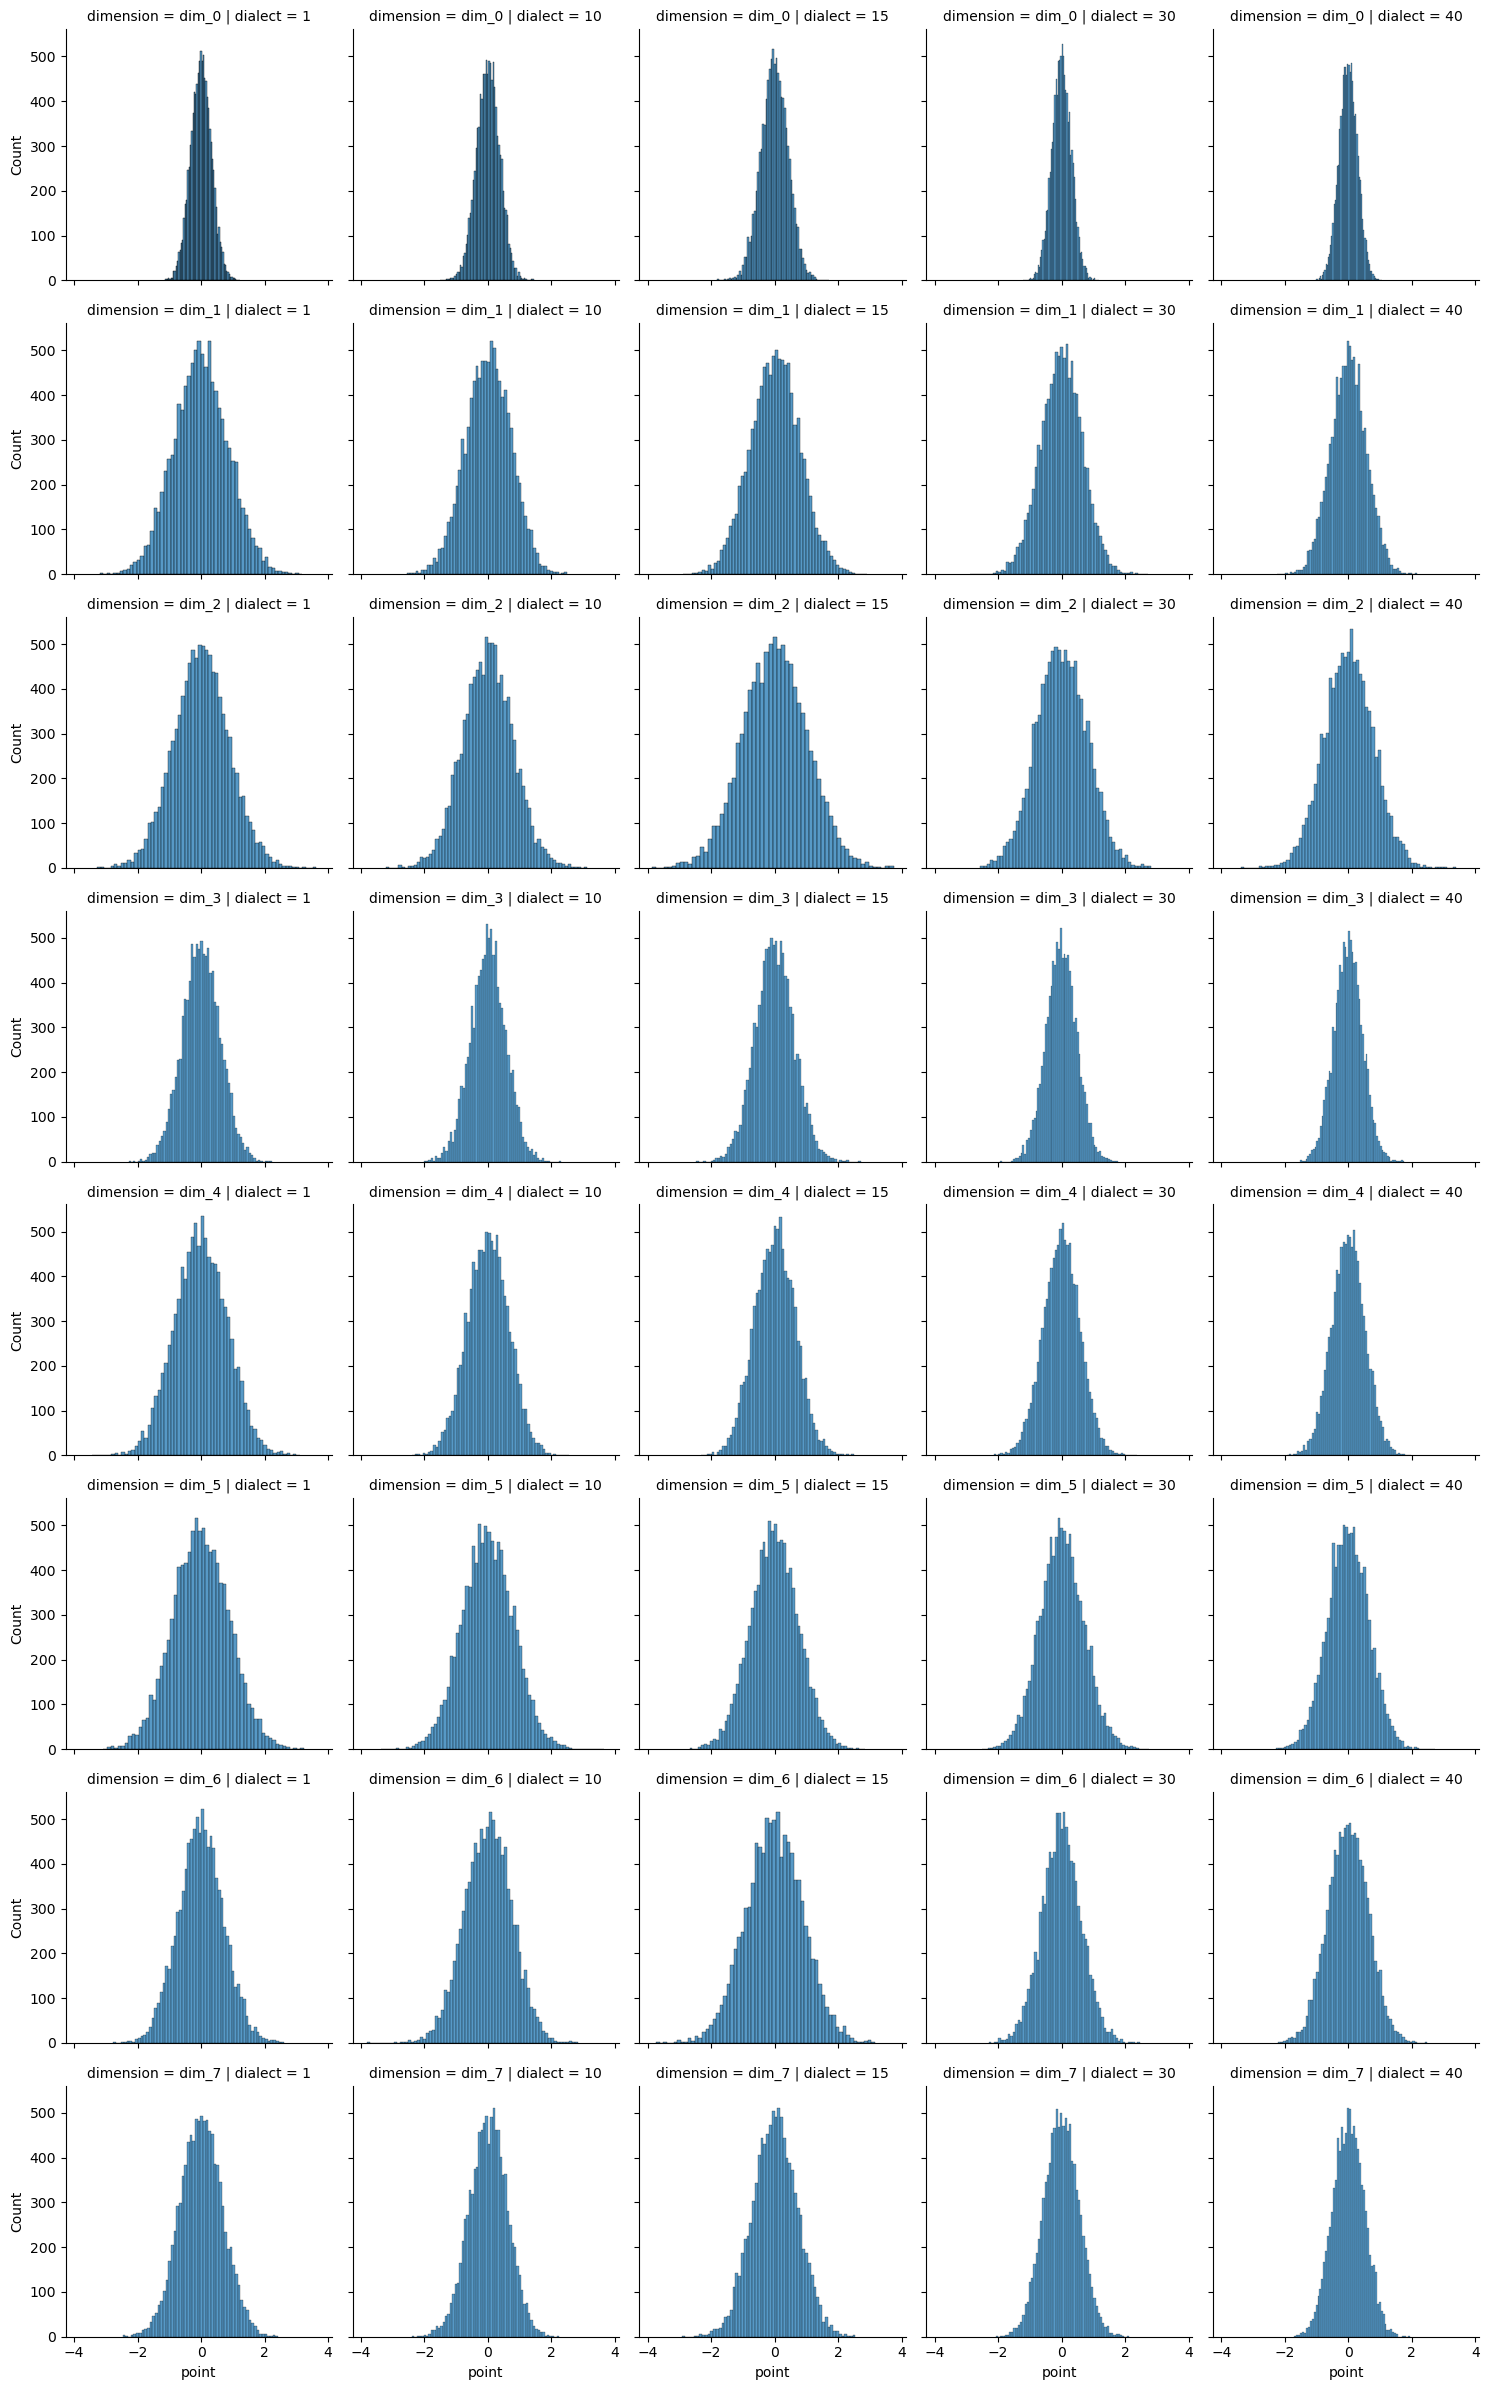

In [29]:
common_50,dialect_50,total_50 = sample_from_dialects(nsamp,O_c,d_c,d,mu,U)

dialects_sample = [dialect_50[i] for i in range(dialect_50.shape[0])]



print(dialect_50.shape)  
print(common_50.shape)   


pts = dialect_50[1].numpy()
print(pts.shape)             
print(len(pts))             
pts_1 = dialect_50[1].numpy()
pts_10 = dialect_50[10].numpy()
pts_40 = dialect_50[40].numpy()
pts_30 = dialect_50[30].numpy()
pts_15 = dialect_50[15].numpy()
def dialect_to_pf(pts,dialect_id):
    df = pd.DataFrame(pts,columns = [f'dim_{i}' for i in range(pts.shape[1])])
    df["dialect"]= dialect_id
    return df
df = pd.concat([
    dialect_to_pf(pts_1,1),
    dialect_to_pf(pts_10,10),
    dialect_to_pf(pts_40,40),
    dialect_to_pf(pts_30,30),
    dialect_to_pf(pts_15,15)

],ignore_index=True)
df.head(10)
df_long = pd.melt(df, id_vars= ["dialect"],
                  value_vars=["dim_0","dim_1","dim_2","dim_3","dim_4","dim_5","dim_6","dim_7"], 
                  var_name = "dimension",
                  value_name = "point")
p = sns.FacetGrid(df_long, col = "dialect",row = "dimension")
p.map(sns.histplot,"point")
                  



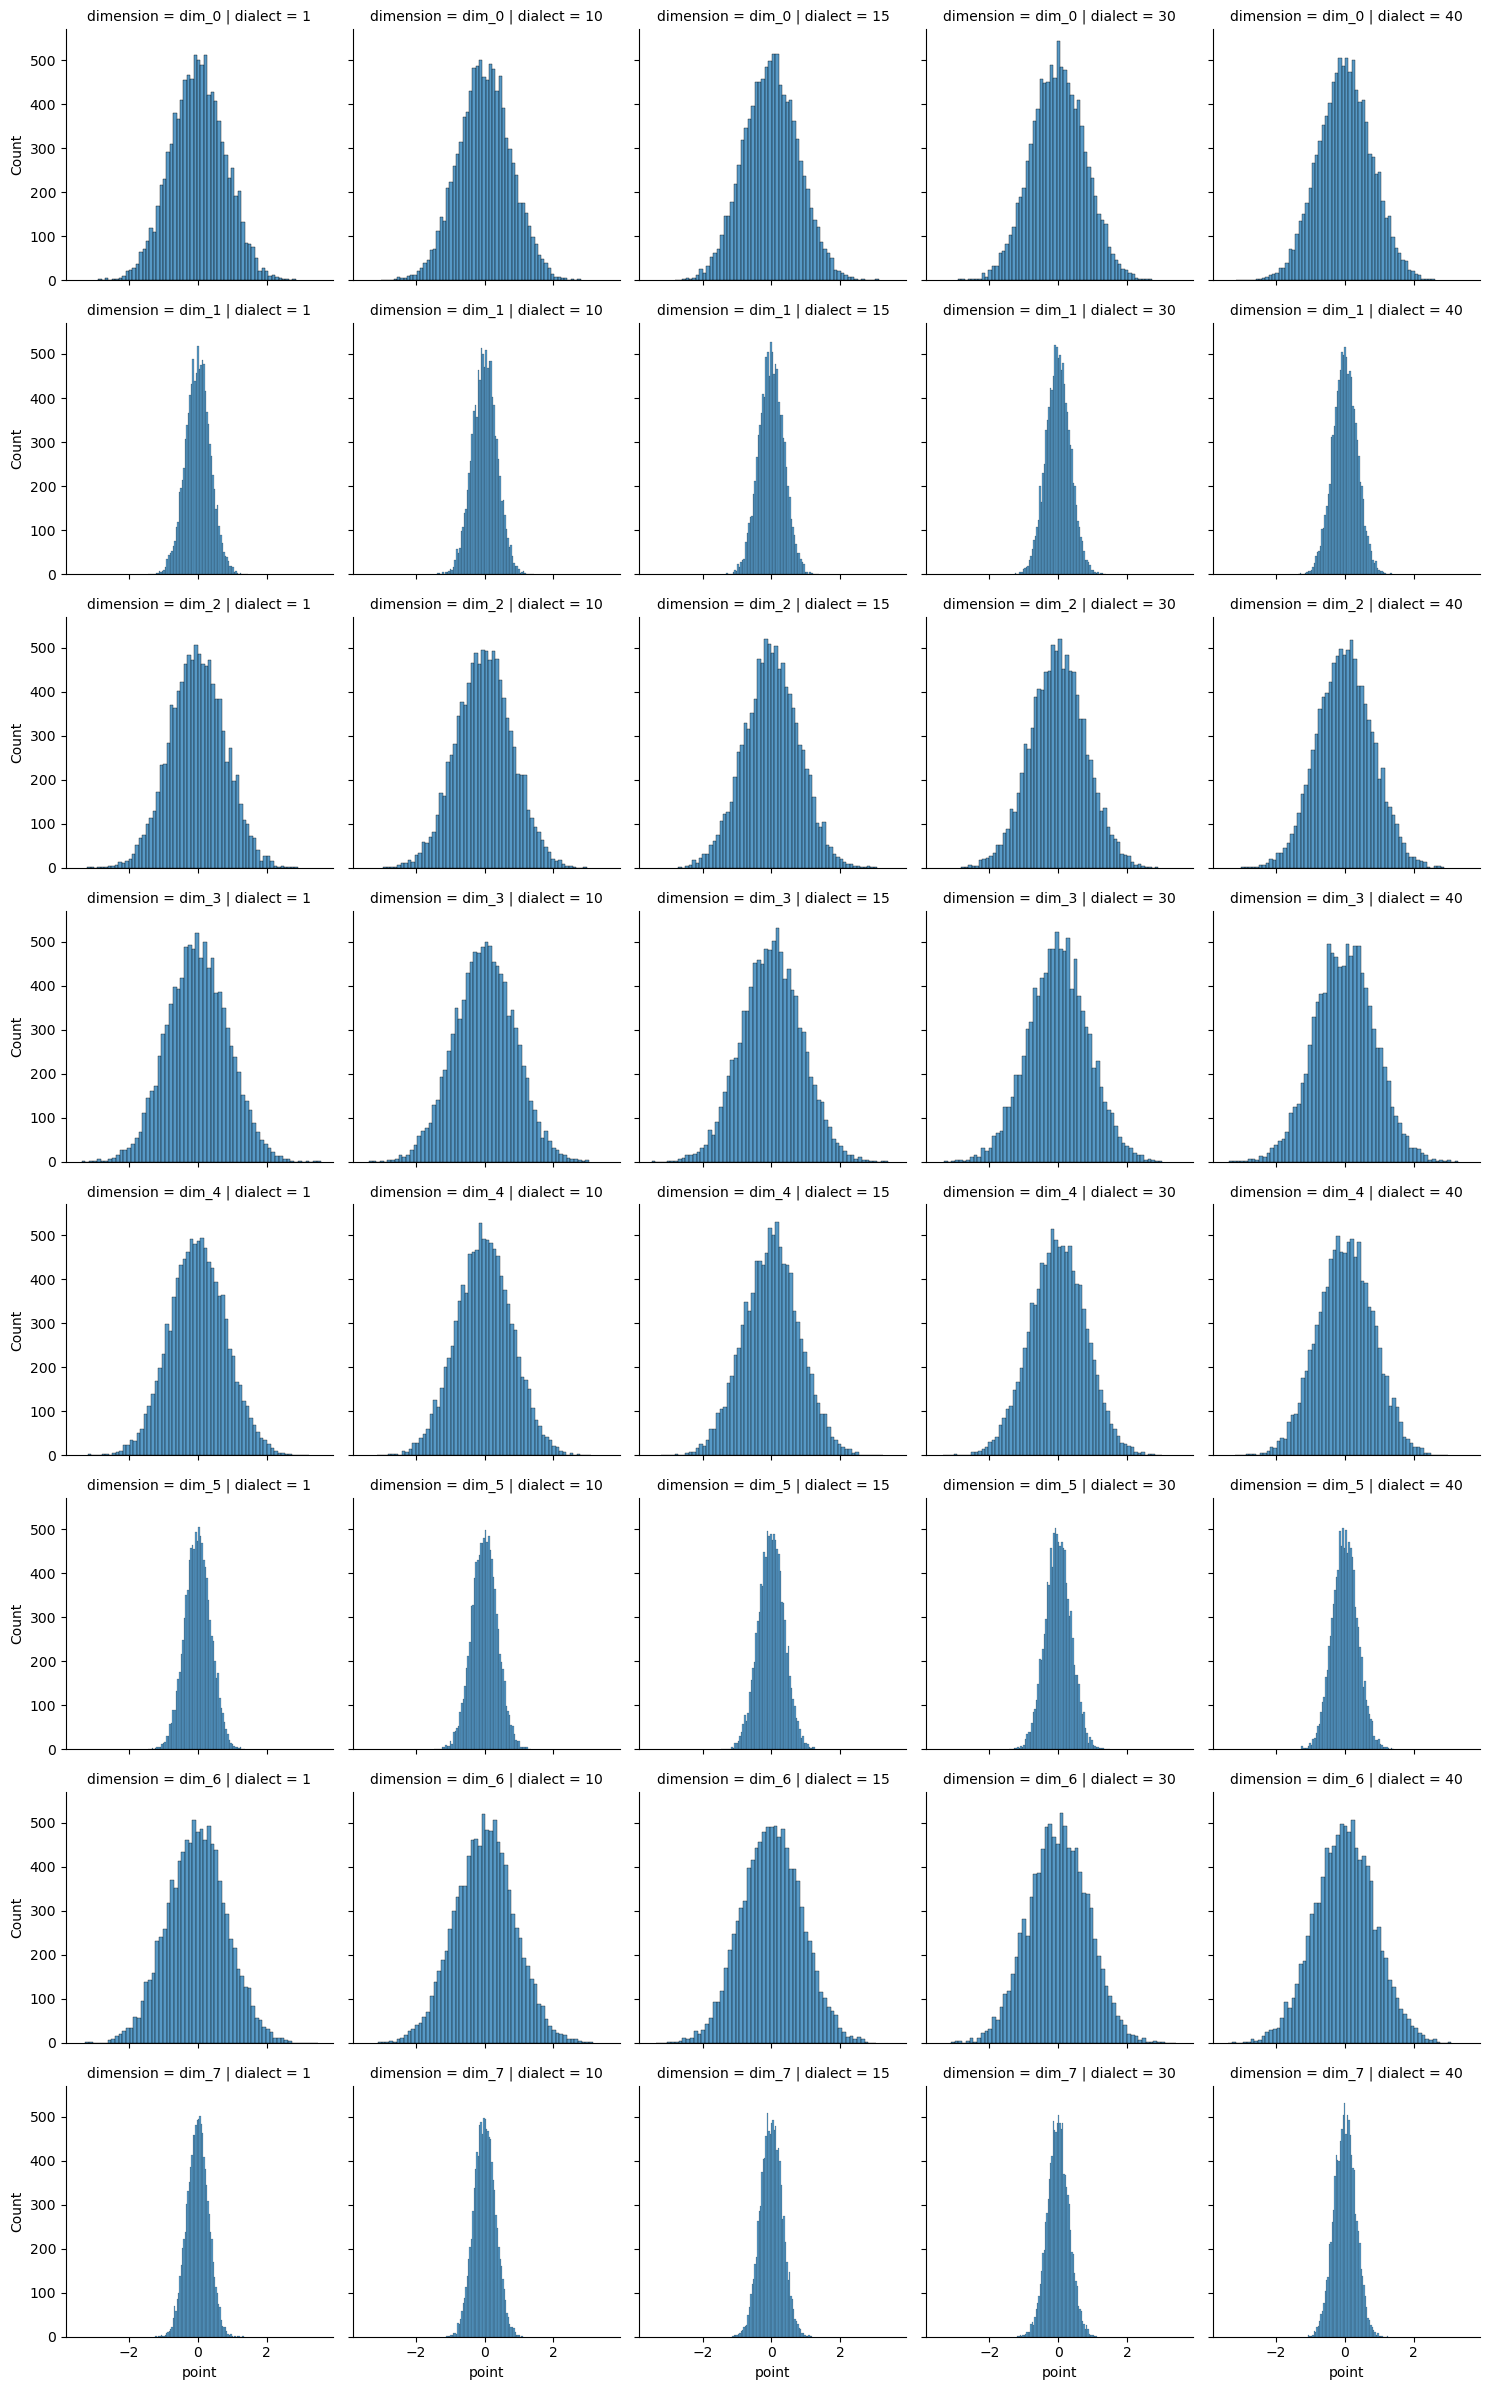

In [21]:
df_common = pd.concat([
    dialect_to_pf(common_50[1].numpy(),1),
    dialect_to_pf(common_50[10].numpy(),10),
    dialect_to_pf(common_50[40].numpy(),40),
    dialect_to_pf(common_50[15].numpy(), 15),
    dialect_to_pf(common_50[30].numpy(),30)
])
common_long = pd.melt(df_common,id_vars = ["dialect"],
                      value_vars = ["dim_0","dim_1","dim_2","dim_3","dim_4","dim_5","dim_6","dim_7"],
                      var_name = "dimension",
                      value_name = "point")
long_grid = sns.FacetGrid(common_long, col = "dialect",row = "dimension")
long_grid.map(sns.histplot,"point")


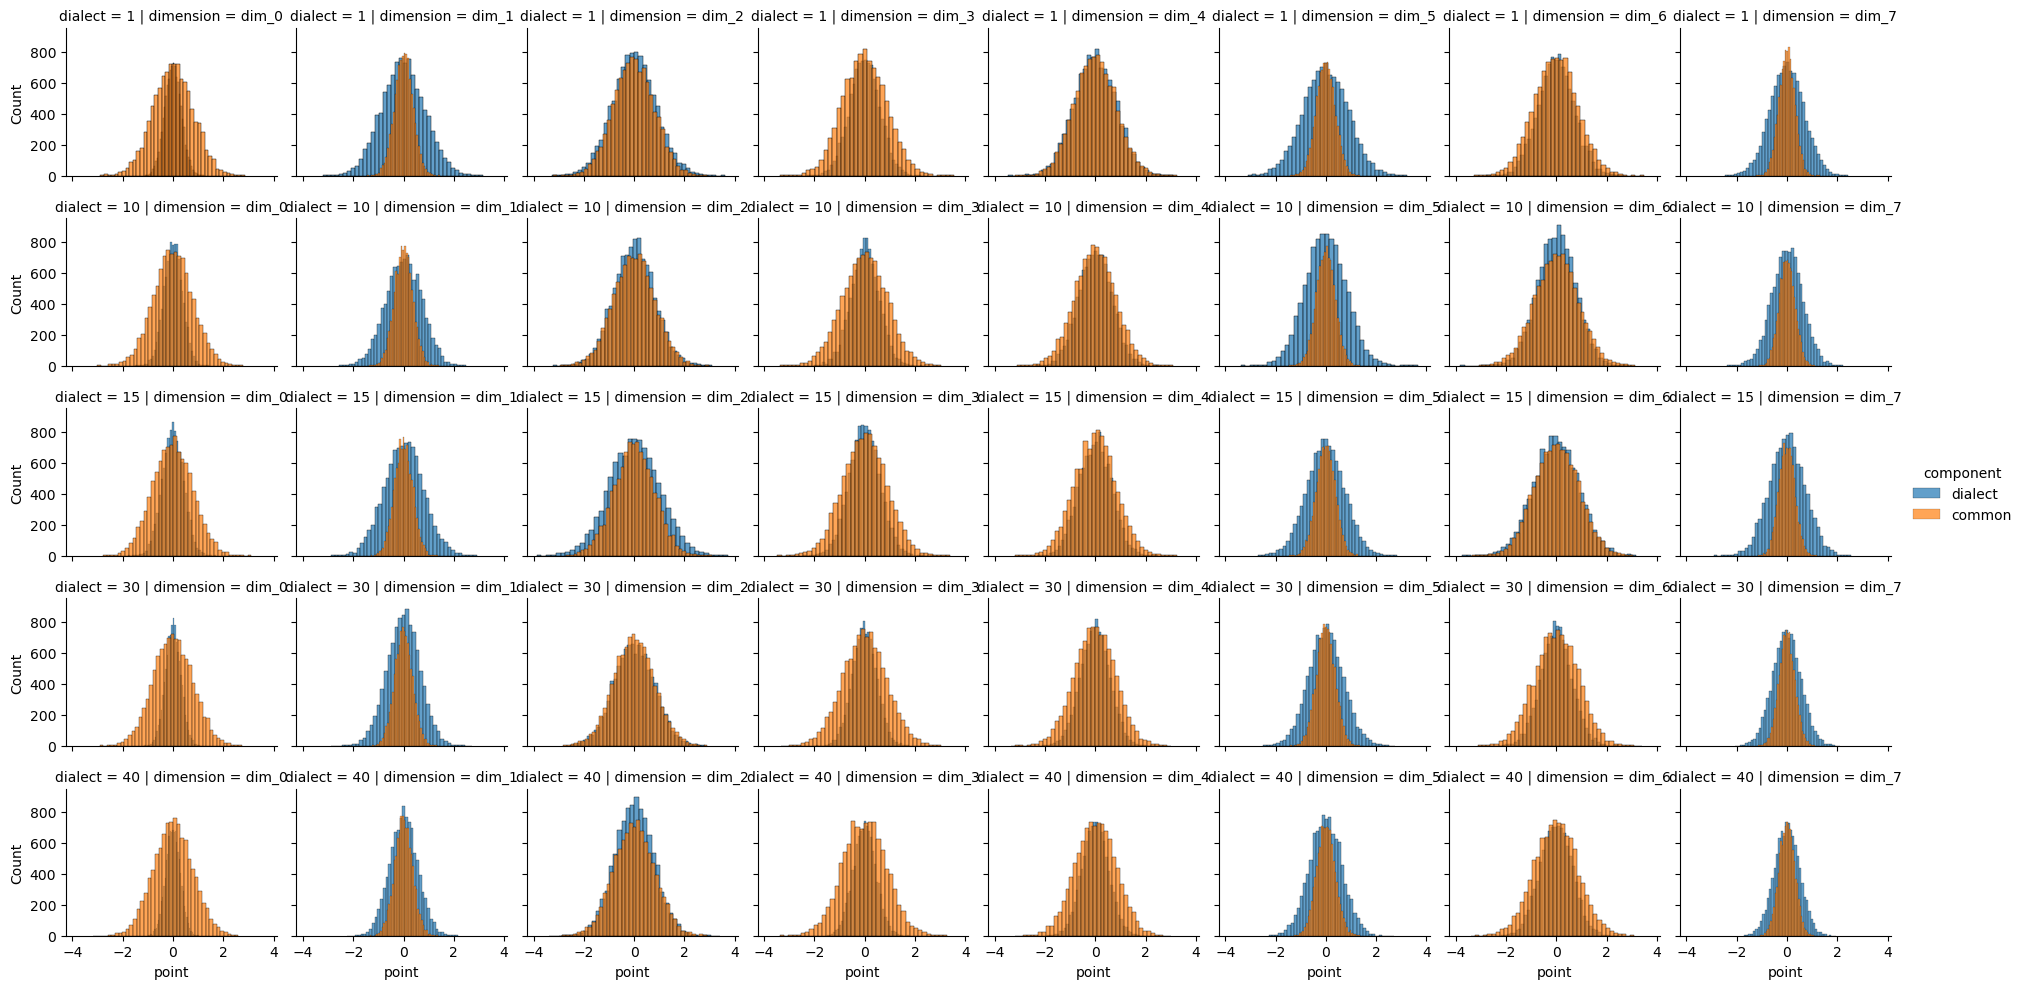

In [30]:
df_long["component"] = "dialect"
common_long["component"] = "common"
total_df = pd.concat([df_long, common_long], ignore_index=True)

total_grid = sns.FacetGrid(total_df, row="dialect", col="dimension", hue="component", height=2, aspect=1.2)
total_grid.map_dataframe(sns.histplot, "point", multiple="dodge", bins=40, alpha=0.7)
total_grid.add_legend()


In [17]:
print(df_long.tail(10))
print(common_long.tail(10))

        dialect dimension     point component
399990       30     dim_7  0.308842   dialect
399991       30     dim_7  1.223060   dialect
399992       30     dim_7  1.075277   dialect
399993       30     dim_7 -1.914716   dialect
399994       30     dim_7  1.734409   dialect
399995       30     dim_7  1.227994   dialect
399996       30     dim_7  0.960359   dialect
399997       30     dim_7  0.120472   dialect
399998       30     dim_7 -0.098298   dialect
399999       30     dim_7  0.434532   dialect
        dialect dimension     point component
399990       30     dim_7  0.308842    common
399991       30     dim_7  1.223060    common
399992       30     dim_7  1.075277    common
399993       30     dim_7 -1.914716    common
399994       30     dim_7  1.734409    common
399995       30     dim_7  1.227994    common
399996       30     dim_7  0.960359    common
399997       30     dim_7  0.120472    common
399998       30     dim_7 -0.098298    common
399999       30     dim_7  0.43453

In [52]:
print(proj.shape)

(50000, 2)


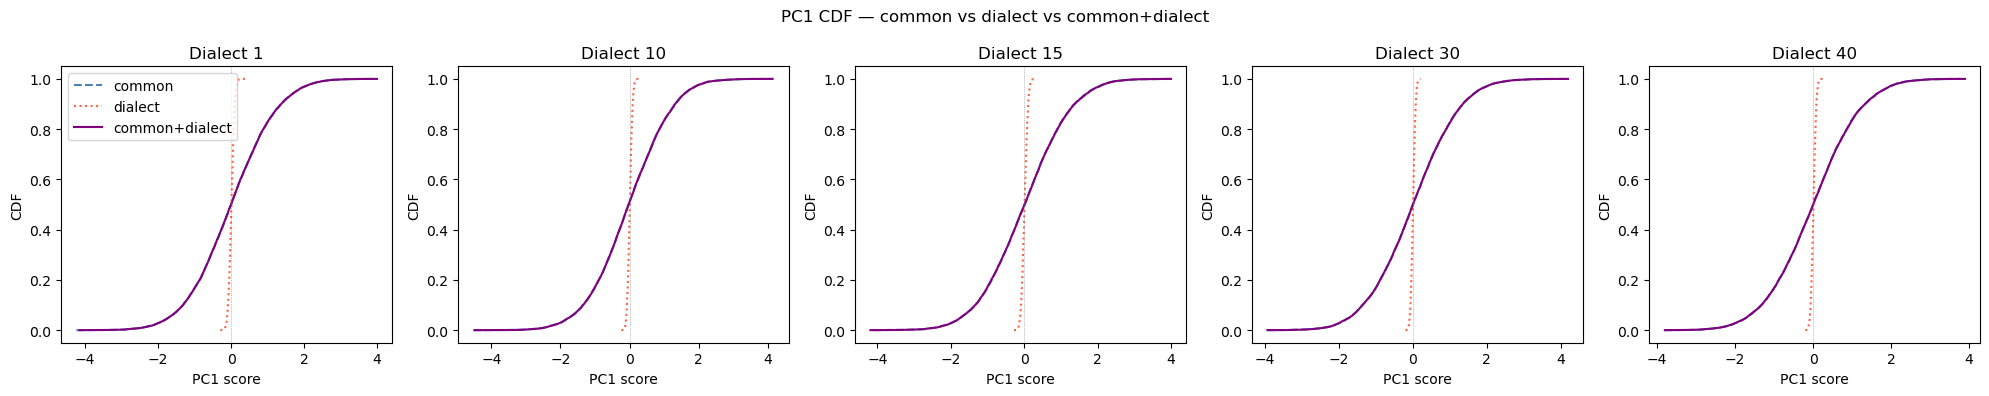

In [59]:
fig, axes = plt.subplots(1,5,figsize = (20,4))
dialects_to_plot = [1,10,15,30,40]
all_cumul = np.vstack([common_50[d].numpy()+dialect_50[d].numpy() for d in dialects_to_plot])
pca = PCA(n_components=2)
pca.fit(all_cumul)
for ax, dial in zip(axes, dialects_to_plot):
    common_vec  = common_50[dial].numpy()
    dialect_vec = dialect_50[dial].numpy()
    cumulative  = common_vec + dialect_vec

    pc1_common  = pca.transform(common_vec)[:, 0]
    pc1_dialect = pca.transform(dialect_vec)[:, 0]   
    pc1_cumul   = pca.transform(cumulative)[:, 0]

    p = np.linspace(0, 1, 10000)
    ax.plot(np.sort(pc1_common),  p, linestyle='--', color='steelblue', label='common')
    ax.plot(np.sort(pc1_dialect), p, linestyle=':',  color='tomato',    label='dialect')  
    ax.plot(np.sort(pc1_cumul),   p, linestyle='-',  color='purple',    label='common+dialect')
    ax.set_title(f'Dialect {dial}')
    ax.set_xlabel('PC1 score')
    ax.set_ylabel('CDF')
    ax.axvline(0, color='gray', lw=0.5, linestyle=':')

axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq


def random_covariance(dim, variances, sigma=1.0):
    A = np.random.normal(0, sigma, size=(dim, dim))
    M = A @ A.T
    scale = np.sqrt(np.asarray(variances) / np.diag(M))
    D = np.diag(scale)
    return D @ M @ D


def make_true_mixture_covariances(dim, target_variances, K, spread=0.5, sigma=1.0):
    target_variances = np.asarray(target_variances, dtype=float)
    raw_diags = []

    for _ in range(K):
        d = target_variances * (1.0 + spread * (2.0 * np.random.rand(dim) - 1.0))
        d = np.maximum(d, 1e-10)
        raw_diags.append(d)

    raw_diags = np.array(raw_diags)
    mean_diag = raw_diags.mean(axis=0)
    corrected_diags = raw_diags * (target_variances / mean_diag)

    covariances = [random_covariance(dim, corrected_diags[k], sigma=sigma) for k in range(K)]
    return covariances


def sample_row_mixture(m, covariances, weights=None):
    K = len(covariances)
    n = covariances[0].shape[0]

    if weights is None:
        weights = np.ones(K) / K
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    comps = np.random.choice(K, size=m, p=weights)
    A = np.zeros((m, n))

    for i, k in enumerate(comps):
        A[i] = np.random.multivariate_normal(np.zeros(n), covariances[k])

    return A, comps


def sample_covariance_matrix(A):
    return (A.T @ A) / A.shape[0]


def mixture_upper_tail(x, sigmas, weights=None):
    sigmas = np.asarray(sigmas, dtype=float)
    if weights is None:
        weights = np.ones(len(sigmas)) / len(sigmas)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    return np.sum(weights * (1.0 - norm.cdf(x / sigmas)))


def mixture_two_sided_tail(x, sigmas, weights=None):
    sigmas = np.asarray(sigmas, dtype=float)
    if weights is None:
        weights = np.ones(len(sigmas)) / len(sigmas)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    return np.sum(weights * 2.0 * (1.0 - norm.cdf(x / sigmas)))


def epsilon_point(sigmas, epsilon=1e-3, weights=None, two_sided=True):
    sigmas = np.asarray(sigmas, dtype=float)

    if weights is None:
        weights = np.ones(len(sigmas)) / len(sigmas)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    tail = mixture_two_sided_tail if two_sided else mixture_upper_tail

    def f(x):
        return tail(x, sigmas, weights) - epsilon

    lo = 0.0
    hi = 10.0 * np.max(sigmas)
    while f(hi) > 0:
        hi *= 2.0

    return brentq(f, lo, hi)


def epsilon_points_all_coordinates(covariances, epsilon=1e-3, weights=None, two_sided=True):
    K = len(covariances)
    n = covariances[0].shape[0]

    if weights is None:
        weights = np.ones(K) / K
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    xeps = np.zeros(n)
    for j in range(n):
        sigmas_j = np.sqrt([covariances[k][j, j] for k in range(K)])
        xeps[j] = epsilon_point(sigmas_j, epsilon=epsilon, weights=weights, two_sided=two_sided)
    return xeps


if __name__ == "__main__":
    np.random.seed(0)

    dim = 4
    variances = [1, 2, 3, 4]
    K = 5
    m = 3000
    epsilon = 1e-3

    covariances = make_true_mixture_covariances(dim, variances, K=K, spread=0.8, sigma=1.0)

    A, comps = sample_row_mixture(m, covariances)
    S = sample_covariance_matrix(A)
    xeps = epsilon_points_all_coordinates(covariances, epsilon=epsilon, two_sided=True)

    print("target diagonal:")
    print(np.array(variances))

    print("\nmixture component diagonals:")
    for k, Sigma in enumerate(covariances):
        print(f"component {k}:", np.diag(Sigma))

    print("\naverage mixture diagonal:")
    print(np.mean([np.diag(Sigma) for Sigma in covariances], axis=0))

    print("\nsample covariance matrix:")
    print(S)

    print("\nsample covariance diagonal:")
    print(np.diag(S))

    print(f"\ntwo-sided epsilon points for epsilon={epsilon}:")
    print(xeps)
